In [42]:
import os
os.getcwd()

'/data/LoRA-FAIR'

#### Baseline for LoRA FAIR for 100 Clients, sampled 0.1 in each round for 50 rounds total

In [ ]:
# Terminal 1: Start training

CUDA_VISIBLE_DEVICES=1 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 100 \
    --client_fraction 0.1 \
    --rounds 75 \
    --local_epochs 5 \
    --batch_size 128 \
    --learning_rate 0.01 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --refinement_iterations 1000 \
    --refinement_lr 0.01 \
    --lambda_reg 0.01 \
    --alpha 1000 \
    --output_dir results \
    --save_model \
    --eval_every 5 > training.log 2>&1 &

### lora_fair for feature non iid (not including labels) for 100 clients, 75 rounds, 10 clients sampled.

In [ ]:
CUDA_VISIBLE_DEVICES=0 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 100 \
    --client_fraction 0.1 \
    --rounds 75 \
    --local_epochs 5 \
    --max_iterations 100 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --learning_rate 0.01 \
    --batch_size 128 \
    --refinement_iterations 1000 \
    --refinement_lr 0.01 \
    --lambda_reg 0.01 \
    --alpha 1000.0 \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    --save_model \
    --eval_every 5 > training.log 2>&1 &

In [ ]:
CUDA_VISIBLE_DEVICES=0 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 6 \
    --client_fraction 1.0 \
    --rounds 30 \
    --local_epochs 1 \
    --max_iterations 2 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --learning_rate 0.01 \
    --batch_size 128 \
    --refinement_iterations 1000 \
    --refinement_lr 0.01 \
    --lambda_reg 0.01 \
    --alpha 1000.0 \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    --eval_every 5 > training.log 2>&1 &

### Main setting

In [ ]:
CUDA_VISIBLE_DEVICES=0 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 100 \
    --client_fraction 1.0 \
    --rounds 75 \
    --local_epochs 1 \
    --max_iterations 10 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --learning_rate 0.01 \
    --batch_size 128 \
    --refinement_iterations 1000 \
    --refinement_lr 0.01 \
    --lambda_reg 0.01 \
    --alpha 1000.0 \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    --eval_every 5 > training.log 2>&1 &

### Plot for training (every round) and eval loss (every 10 rounds)

In [43]:
import json
import time
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, clear_output

result_file = Path('results/lora_fair_feature_noniid_100c_75r/results_lora_fair_nicopp.json')

# We don't need plt.ion() or matplotlib.use('Agg') here
# because Jupyter handles the inline display automatically.

print("Monitoring training... Stop the cell to stop.")

try:
    while True:
      
        if result_file.exists():
            print("file exists")
            with open(result_file) as f:
                data = json.load(f)
            
            # 1. Clear the previous plot in the Jupyter cell
            clear_output(wait=True)
            
            # 2. Create the figure
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Plot Loss
            # Plot Loss
            if 'round_losses' in data and data['round_losses']:
                losses = data['round_losses']
                # FIX: Slice rounds to match the current number of loss entries
                rounds = data['round'][:len(losses)] 
                
                ax1.plot(rounds, losses, 'b-o', linewidth=2, markersize=4)
                ax1.set_xlabel('Round')
                ax1.set_ylabel('Loss')
                ax1.set_title(f'Training Loss (Current: {losses[-1]:.4f})', fontweight='bold')
                ax1.grid(True, alpha=0.3)
            if 'avg_top1' in data and data['avg_top1']:
                # IMPORTANT: If accuracy is only recorded every 'eval_every' rounds,
                # make sure acc_rounds matches the length of accs.
                accs = data['avg_top1']
                acc_rounds = data['round'][:len(accs)] # Adjusting if lengths differ
                
                ax2.plot(acc_rounds, accs, 'g-o', linewidth=2, markersize=4)
                ax2.set_xlabel('Evaluation Round')
                ax2.set_ylabel('Accuracy (%)')
                ax2.set_title(f'Test Accuracy (Current: {accs[-1]:.2f}%)', fontweight='bold')
                ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()

            clear_output(wait=True)
            display(fig)
            plt.close(fig) 
            
            print(f"Last updated: {time.strftime('%H:%M:%S')}")
            time.sleep(10)
        else:
            clear_output(wait=True)
            print("file doesn't exists")
            print(f"Waiting for {result_file}...")
            time.sleep(10)
            
except KeyboardInterrupt:
    plt.close()
    print("Monitoring stopped")

file doesn't exists
Waiting for data/LoRA-FAIR/results/flora_baseline_nicopp/results_flora_nicopp_ViT_homo_r75_c100_f0p1_ep5_lr0p01_a1000p0_s42.json...
Monitoring stopped


### FloRA baseline on NICO++ dataset, feature Non IID, 100 clients, 75 rounds, 0.1 sampling of clients per round.

In [ ]:
CUDA_VISIBLE_DEVICES=0 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 100 \
    --client_fraction 0.1 \
    --rounds 75 \
    --local_epochs 5 \
    --max_iterations 100 \
    --lora_rank 16 \
    --aggregation flora \
    --learning_rate 0.01 \
    --batch_size 128 \
    --alpha 1000.0 \
    --output_dir results/flora_baseline_nicopp \
    --save_model \
    --eval_every 5 > training.log 2>&1 &

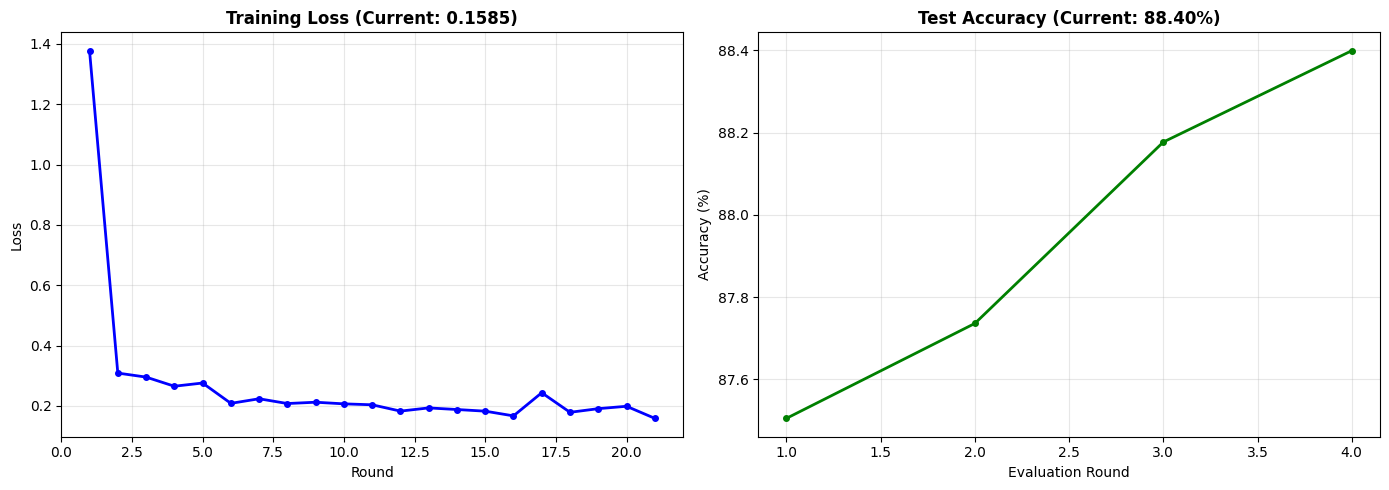

Last updated: 03:08:40


In [ ]:
import json
import time
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, clear_output

result_file = Path('results/flora_baseline_nicopp/results_flora_nicopp_ViT_homo_r75_c100_f0p1_ep5_lr0p01_a1000p0_s42.json')

# We don't need plt.ion() or matplotlib.use('Agg') here
# because Jupyter handles the inline display automatically.

print("Monitoring training... Stop the cell to stop.")

try:
    while True:
      
        if result_file.exists():
            print("file exists")
            with open(result_file) as f:
                data = json.load(f)
            
            # 1. Clear the previous plot in the Jupyter cell
            clear_output(wait=True)
            
            # 2. Create the figure
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
            
            # Plot Loss
            # Plot Loss
            if 'round_losses' in data and data['round_losses']:
                losses = data['round_losses']
                # FIX: Slice rounds to match the current number of loss entries
                rounds = data['round'][:len(losses)] 
                
                ax1.plot(rounds, losses, 'b-o', linewidth=2, markersize=4)
                ax1.set_xlabel('Round')
                ax1.set_ylabel('Loss')
                ax1.set_title(f'Training Loss (Current: {losses[-1]:.4f})', fontweight='bold')
                ax1.grid(True, alpha=0.3)
            if 'avg_top1' in data and data['avg_top1']:
                # IMPORTANT: If accuracy is only recorded every 'eval_every' rounds,
                # make sure acc_rounds matches the length of accs.
                accs = data['avg_top1']
                acc_rounds = data['round'][:len(accs)] # Adjusting if lengths differ
                
                ax2.plot(acc_rounds, accs, 'g-o', linewidth=2, markersize=4)
                ax2.set_xlabel('Evaluation Round')
                ax2.set_ylabel('Accuracy (%)')
                ax2.set_title(f'Test Accuracy (Current: {accs[-1]:.2f}%)', fontweight='bold')
                ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()

            clear_output(wait=True)
            display(fig)
            plt.close(fig) 
            
            print(f"Last updated: {time.strftime('%H:%M:%S')}")
            time.sleep(10)
        else:
            clear_output(wait=True)
            print("file doesn't exists")
            print(f"Waiting for {result_file}...")
            time.sleep(10)
            
except KeyboardInterrupt:
    plt.close()
    print("Monitoring stopped")

In [ ]:
COMMON_ARGS="
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 100 \
    --client_fraction 0.1 \
    --rounds 75 \
    --local_epochs 5 \
    --max_iterations 100 \
    --lora_rank 16 \
    --learning_rate 0.01 \
    --batch_size 128 \
    --alpha 1000.0 \
    --save_model \
    --eval_every 5
"

CUDA_VISIBLE_DEVICES=1 nohup python main.py $COMMON_ARGS \
    --aggregation fedit \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    > fl_nicopp_logs/fedit_nicopp_100c_75r.log 2>&1 &
echo "fedit PID: $!"

CUDA_VISIBLE_DEVICES=2 nohup python main.py $COMMON_ARGS \
    --aggregation ffa \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    > fl_nicopp_logs/ffa_nicopp_100c_75r.log 2>&1 &
echo "ffa PID: $!"

CUDA_VISIBLE_DEVICES=3 nohup python main.py $COMMON_ARGS \
    --aggregation flex \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    > fl_nicopp_logs/flex_nicopp_100c_75r.log 2>&1 &
echo "flex PID: $!"

CUDA_VISIBLE_DEVICES=4 nohup python main.py $COMMON_ARGS \
    --aggregation florist \
    --output_dir results/lora_fair_feature_noniid_100c_75r \
    > fl_nicopp_logs/florist_nicopp_100c_75r.log 2>&1 &
echo "florist PID: $!"

echo "All 4 methods launched in parallel!"

In [ ]:
"""Generate final plots after training"""

import json
import matplotlib.pyplot as plt
from pathlib import Path

# Load results
result_file = 'results/flora_baseline_nicopp/results_flora_nicopp_ViT_homo_r75_c100_f0p1_ep5_lr0p01_a1000p0_s42.json'
with open(result_file) as f:
    data = json.load(f)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss curve
ax1 = axes[0]
if 'round_losses' in data:
    ax1.plot(data['round'], data['round_losses'], 'b-o', linewidth=2, markersize=5)
    ax1.set_xlabel('Round', fontsize=12)
    ax1.set_ylabel('Average Loss', fontsize=12)
    ax1.set_title('Training Loss Curve', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2 = axes[1]
if 'avg_top1' in data:
    ax2.plot(data['round'], data['avg_top1'], 'g-o', linewidth=2, markersize=5, label='Top-1')
    if 'avg_top5' in data:
        ax2.plot(data['round'], data['avg_top5'], 'r-s', linewidth=2, markersize=5, label='Top-5')
    ax2.set_xlabel('Round', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('Test Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/lora_fair_plots/lora_fair_training_curves_1.png', dpi=150, bbox_inches='tight')
print("✓ Saved to results/training_curves.png")
plt.show()

## Baseline for table 2 - Lora Fair and Fed IT (to confirm parameters like max iterations)

In [ ]:
CUDA_VISIBLE_DEVICES=0 nohup python main.py \
  --dataset nicopp \
  --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
  --aggregation fedit \
  --num_classes 60 \
  --clients 6 \
  --rounds 30 \
  --local_epochs 1 \
  --max_iterations 2 \
  --batch_size 128 \
  --learning_rate 0.01 \
  --lora_rank 16 \
  --output_dir results/lora_fair_table_2_baseline \
  --save_model \
  --seed 42

In [ ]:
CUDA_VISIBLE_DEVICES=1 nohup python main.py \
  --dataset nicopp \
  --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
  --aggregation lora_fair \
  --num_classes 60 \
  --clients 6 \
  --rounds 30 \
  --local_epochs 1 \
  --max_iterations 2 \
  --batch_size 128 \
  --learning_rate 0.01 \
  --lora_rank 16 \
  --refinement_iterations 1000 \
  --refinement_lr 0.01 \
  --lambda_reg 0.01 \
  --output_dir results/lora_fair_table_2_baseline \
  --save_model \
  --seed 42 > training.log 2>&1 &

### Reproducing table 3 for LoRA FAIR and Fed IT 

In [ ]:
CUDA_VISIBLE_DEVICES=2 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 30 \
    --client_fraction 0.6 \
    --rounds 30 \
    --local_epochs 1 \
    --max_iterations 5 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --learning_rate 0.01 \
    --batch_size 128 \
    --refinement_iterations 5000 \
    --refinement_lr 0.01 \
    --lambda_reg 0.01 \
    --alpha 0.5 \
    --output_dir results/lora_fair_table3_baseline_cosine0_mi5k \
    --eval_every 5 > table3_lora_fair_cosine0_mi5k.log 2>&1 &

In [ ]:
CUDA_VISIBLE_DEVICES=3 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 30 \
    --client_fraction 0.6 \
    --rounds 30 \
    --local_epochs 1 \
    --max_iterations 5 \
    --lora_rank 16 \
    --aggregation fedit \
    --learning_rate 0.01 \
    --batch_size 128 \
    --alpha 0.5 \
    --output_dir results/lora_fair_table_3_baseline \
    --eval_every 5 > table3_fedit.log 2>&1 &

In [ ]:
CUDA_VISIBLE_DEVICES=3 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 30 \
    --client_fraction 0.6 \
    --rounds 30 \
    --local_epochs 1 \
    --max_iterations 5 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --learning_rate 0.01 \
    --batch_size 128 \
    --refinement_iterations 1000 \
    --refinement_lr 0.001 \
    --lambda_reg 0.01 \
    --alpha 0.5 \
    --output_dir results/lora_fair_table3_baseline_cosine1_5klr_001 \
    --eval_every 5 > table3_lora_fair_cosine1_5klr_001.log 2>&1 &

In [ ]:
CUDA_VISIBLE_DEVICES=3 nohup python main.py \
    --dataset nicopp \
    --data_path /projects/bewi/hramesh/SpecTraL/datasets/Nico++ \
    --model ViT \
    --num_classes 60 \
    --clients 100 \
    --client_fraction 0.1 \
    --rounds 75 \
    --local_epochs 1 \
    --max_iterations 5 \
    --lora_rank 16 \
    --aggregation lora_fair \
    --learning_rate 0.01 \
    --batch_size 128 \
    --refinement_iterations 5000 \
    --refinement_lr 0.001 \
    --lambda_reg 0.01 \
    --alpha 0.5 \
    --output_dir results/lora_fair_nicopp_100c_75c_mi5k \
    --eval_every 10 > lora_fair_nicopp_100c_75c_mi5k.log 2>&1 &